In [ ]:
import re
import pandas as pd


def clean_text(text: str) -> str:
    text = str(text).lower()

    # Normalize financial tokens BEFORE stripping symbols
    text = re.sub(r'\$([a-zA-Z]{1,5})', r'ticker \1', text)     # $AAPL → ticker aapl
    text = re.sub(r'(\d+\.?\d*)\s*%', r'\1 percent', text)       # 3.5% → 3.5 percent
    text = re.sub(r'\$[\d,.]+[bmk]?', 'dollar amount', text)     # $4.2B → dollar amount

     # Strip URLs and HTML
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
 
    # Remove special chars, keep alphanumeric + spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# load if starting fresh
# df_raw = pd.read_csv('raw_news_multiple_companies.csv')

df_raw = pd.read_csv('../data/raw_news_multiple_companies.csv')


# Combine headline and summary
df_raw['text'] = (
    df_raw['headline'].fillna('') + ". " +
    df_raw['summary'].fillna('')
).str.strip()


# Applying cleaning 
df_raw['text'] = df_raw['text'].apply(clean_text)

# Remove duplicates
df_raw = df_raw.drop_duplicates(subset=['text'])

# Remove very short text (less than 10 shorts chars)
df_raw = df_raw[df_raw['text'].str.len() >=40]

# Reset index
df_raw = df_raw.reset_index(drop=True)
print(f"After cleaning: {len(df_raw)} articles")
df_raw[['company','text']].head()

After cleaning: 10765 articles


,company,text
0,AAPL,Apple Inc. (NASDAQ:AAPL) Shines in Caviar Crui...
1,AAPL,Intel (INTC) Is Up 16.0% After Securing Prelim...
2,AAPL,MP Materials Corp (MP) Q1 2026 Earnings Call H...
3,AAPL,Intel Apple Chip Deal Puts Foundry Ambitions A...
4,AAPL,"Apple reaches chipmaking deal with Intel, push..."


In [ ]:
from  transformers import pipeline
import pandas as pd

# Load FinBERT (specialized for financial sentiment)
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    device=-1,  # use CPU, change to 0 for GPU
    truncation=True,
    max_length=512,
    batch_size=32,
)

print(f"Labeling {len(df_raw):,} articles...")
raw_results = finbert(df_raw['text'].tolist())


# Label all texts
print("Labeling with FinBERT...")

# Extract labels and scores
df_raw['sentiment'] = [r['label'].lower() for r in raw_results]
df_raw['confidence'] = [round(r['score'], 4) for r in raw_results]

print("\nSentiment distribution:")
print(df_raw['sentiment'].value_counts())
print(f"\nAverage confidence: {df_raw['confidence'].mean():.2f}")

print(f"Confidence by class:")
print(df_raw.groupby('sentiment')['confidence'].describe().round(3))

bins   = [0, 0.60, 0.70, 0.75, 0.80, 0.90, 1.01]
labels = ['<0.60', '0.60-0.70', '0.70-0.75', '0.75-0.80', '0.80-0.90', '>0.90']
df_raw['conf_bucket'] = pd.cut(df_raw['confidence'], bins=bins, labels=labels, right=False)
print("\nArticles per confidence bucket:")
print(df_raw['conf_bucket'].value_counts().sort_index())

CONFIDENCE_CUTOFF = 0.75
df_clean =(
    df_raw[df_raw['confidence'] >= CONFIDENCE_CUTOFF]
    .drop(columns=['conf_bucket'])
    .copy()
    .reset_index(drop=True)
)
dropped = len(df_raw) - len(df_clean)
print(f"\nKept: {len(df_clean)} articles, avg conf: {df_clean['confidence'].mean():.3f}")
print(f"Dropped: {dropped:,} articles below {CONFIDENCE_CUTOFF}")

print("\nClass distribution after filtering:")
print(df_clean['sentiment'].value_counts())
print("\nClass balance %:")
print((df_clean['sentiment'].value_counts(normalize=True) * 100).round(1))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Labeling with FinBERT...
Processed 16/10803 articles
Processed 176/10803 articles
Processed 336/10803 articles
Processed 496/10803 articles
Processed 656/10803 articles
Processed 816/10803 articles
Processed 976/10803 articles
Processed 1136/10803 articles
Processed 1296/10803 articles
Processed 1456/10803 articles
Processed 1616/10803 articles
Processed 1776/10803 articles
Processed 1936/10803 articles
Processed 2096/10803 articles
Processed 2256/10803 articles
Processed 2416/10803 articles
Processed 2576/10803 articles
Processed 2736/10803 articles
Processed 2896/10803 articles
Processed 3056/10803 articles
Processed 3216/10803 articles
Processed 3376/10803 articles
Processed 3536/10803 articles
Processed 3696/10803 articles
Processed 3856/10803 articles
Processed 4016/10803 articles
Processed 4176/10803 articles
Processed 4336/10803 articles
Processed 4496/10803 articles
Processed 4656/10803 articles
Processed 4816/10803 articles
Processed 4976/10803 articles
Processed 5136/10803 ar

Low confidence (<0.80): 3336 articles (30.9)%
            count      mean       std     min      25%     50%       75%  \
sentiment                                                                  
negative   1962.0  0.920041  0.061124  0.7501  0.88985  0.9460  0.967975   
neutral    3037.0  0.879057  0.052506  0.7502  0.84210  0.8925  0.921800   
positive   3208.0  0.901232  0.055958  0.7504  0.86710  0.9237  0.946300   

              max  
sentiment          
negative   0.9768  
neutral    0.9562  
positive   0.9613  


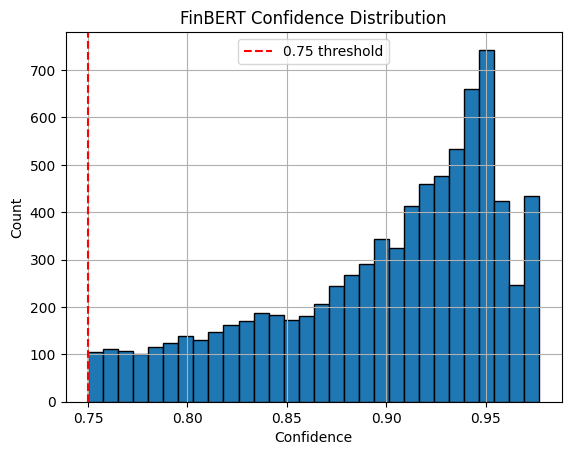

In [7]:
import matplotlib.pyplot as plt

low_conf = df_raw[df_raw['confidence'] < 0.80]
print(f"Low confidence (<0.80): {len(low_conf)} articles ({len(low_conf)/len(df_raw) *100:.1f})%")

print(df_clean.groupby('sentiment')['confidence'].describe())

df_clean['confidence'].hist(bins=30, edgecolor='black')
plt.title('FinBERT Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.axvline(0.75, color='red', linestyle='--', label='0.75 threshold')
plt.legend()
plt.show()

In [8]:
df_clean.to_csv('../data/labeled_news.csv', index=False)
print(f"Saved {len(df_clean)} articles to labeled_news.csv")

Saved 8207 articles to labeled_news.csv
